# Programming Assignment 1

Segmentação de instâncias com as arquiteturas da aula

Equipe: Jaime Willian Carneiro da Silva & Luiz Eduardo Bravin

In [107]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader, random_split, Dataset
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

Escolheremos a opção A - DSB2018 / BBBC038v1

Download:  https://bbbc.broadinstitute.org/BBBC038

In [108]:
def generate_image(img_size: int, seed: int = 0):
    image = np.zeros((img_size, img_size, 3), dtype= np.uint8)
    rng = np.random.default_rng(seed=seed)
    num_ellipses = int(rng.integers(5, 21))
    masks = np.zeros((num_ellipses, img_size, img_size), dtype= np.uint8)
    
    for idx in range(num_ellipses):
        center = tuple(rng.integers(0, img_size + 1, size=2).tolist())
        axes = tuple(rng.integers(5, 41, size=2).tolist())
        angle = int(rng.integers(0, 101))
        color = tuple(rng.integers(50, 256, size=3).tolist())
    
        cv.ellipse(image, center, axes, angle, 0, 360, color, -1)
        cv.ellipse(masks[idx], center, axes, angle, 0, 360, 1, -1)
        
    contrast = rng.random() + 0.5
    noise = rng.integers(-20, 20, size=(img_size, img_size, 3))
    image = (image * contrast) + noise
    image = np.clip(image, 0 , 255 ).astype(np.uint8)

    return image, num_ellipses, masks

In [109]:
class cDatasetBinary(Dataset):
    def __init__(self, num_samples: int, img_size: int = 128) -> None:
        super().__init__()
        self.num_samples = num_samples
        self.img_size = img_size

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        image, _, masks = generate_image(self.img_size, seed=idx)
        image = image.transpose((2, 0, 1))
        image_tensor = torch.from_numpy(image).float() / 255.0
        binary_mask = (masks.sum(axis=0) > 0).astype(np.float32)
        mask_tensor = torch.from_numpy(binary_mask).unsqueeze(0)
        return image_tensor, mask_tensor

class UNetBinary(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        
        # ENCODER
        self.enc1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu) # 64x64
        self.pool = resnet.maxpool # 32x32
        self.enc2 = resnet.layer1  # 32x32, 64 canais
        self.enc3 = resnet.layer2  # 16x16, 128 canais
        self.enc4 = resnet.layer3  # 8x8, 256 canais

        # DECODER
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = nn.Sequential(nn.Conv2d(256, 128, kernel_size=3, padding=1), nn.ReLU())
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(128, 64, kernel_size=3, padding=1), nn.ReLU())
        self.up1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(128, 64, kernel_size=3, padding=1), nn.ReLU())
        self.up0 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.final_conv = nn.Conv2d(32, 1, kernel_size=1) # Saída de 1 canal

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1))
        x3 = self.enc3(x2)
        x4 = self.enc4(x3)

        d3 = self.dec3(torch.cat([self.up3(x4), x3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), x2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), x1], dim=1))
        
        return self.final_conv(self.up0(d1))

In [110]:
dataset = cDatasetBinary(num_samples=500, img_size=128)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNetBinary().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 5
num_batchs = len(dataloader)

for epoch in range(num_epochs):
    model.train()
    accumulated_loss = 0.0
    accumulated_iou = 0.0
    accumulated_dice = 0.0
    
    for images, masks in dataloader:
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        prediction = model(images)
        loss = criterion(prediction, masks)
        loss.backward()
        optimizer.step()

        binary_prediction = (torch.sigmoid(prediction) > 0.5).float()
        intersection = (binary_prediction * masks).sum()
        union = binary_prediction.sum() + masks.sum() - intersection + 1e-6
        
        accumulated_loss += loss.item()
        accumulated_iou += (intersection / union).item()
        accumulated_dice += ((2.0 * intersection) / (union + intersection)).item()
        
    print(f"Época {epoch+1}/{num_epochs} | Loss: {accumulated_loss/num_batchs:.4f} | IoU Semântico: {accumulated_iou/num_batchs:.4f} | Dice: {accumulated_dice/num_batchs:.4f}")


Época 1/5 | Loss: 0.1868 | IoU Semântico: 0.8979 | Dice: 0.9355
Época 2/5 | Loss: 0.0260 | IoU Semântico: 0.9836 | Dice: 0.9917
Época 3/5 | Loss: 0.0118 | IoU Semântico: 0.9941 | Dice: 0.9970
Época 4/5 | Loss: 0.0062 | IoU Semântico: 0.9974 | Dice: 0.9987
Época 5/5 | Loss: 0.0038 | IoU Semântico: 0.9984 | Dice: 0.9992


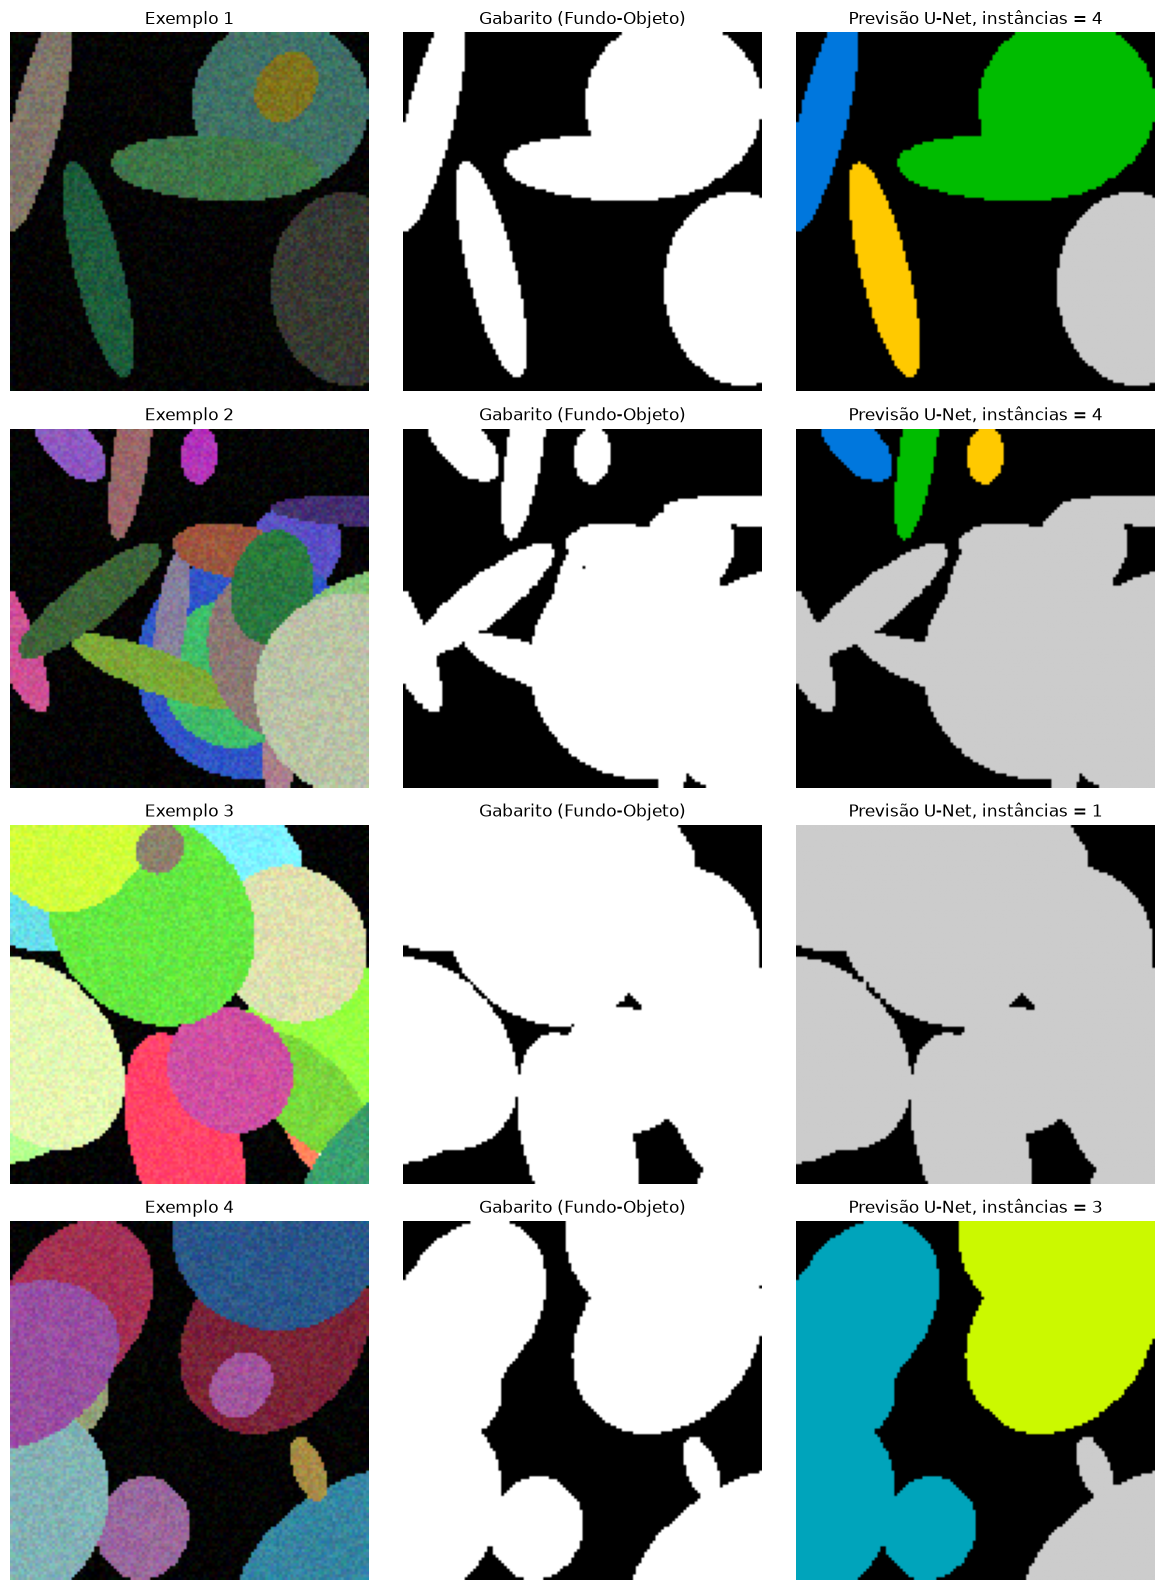

In [130]:
images, real_masks = next(iter(dataloader))
model.eval()

with torch.no_grad():
    # Limiar de 0.5
    prediction_masks_tensor = (torch.sigmoid(model(images.to(device))) > 0.5).float()

images = images.numpy()
real_masks = real_masks.numpy()
prediction_masks = prediction_masks_tensor.cpu().numpy()

num_exemplos = 4
fig, axs = plt.subplots(num_exemplos, 3, figsize=(12, 4 * num_exemplos))

for i in range(num_exemplos):
    # (Canais, Altura, Largura) -> (Altura, Largura, Canais)
    img_vis = images[i].transpose((1, 2, 0))
    
    mask_real_vis = real_masks[i][0]
    mask_prev_vis = prediction_masks[i][0]

    num_labels, instance_mask = cv.connectedComponents(mask_prev_vis.astype(np.uint8))

    # Coluna 1: Imagem
    axs[i, 0].imshow(img_vis)
    axs[i, 0].set_title(f"Exemplo {i+1}")
    axs[i, 0].axis('off')

    # Coluna 2: Gabarito
    axs[i, 1].imshow(mask_real_vis, cmap='gray')
    axs[i, 1].set_title("Gabarito (Fundo-Objeto)")
    axs[i, 1].axis('off')

    # Coluna 3: Previsão U-Net
    axs[i, 2].imshow(instance_mask, cmap='nipy_spectral')
    axs[i, 2].set_title(f"Previsão U-Net, instâncias = {num_labels - 1}")
    axs[i, 2].axis('off')

plt.tight_layout()
plt.show()